# Week - 11

Filtered food webs by size: kept 160 / 290 (>= 40 nodes).


/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_98531/2713449295.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_98531/2713449295.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_98531/2713449295.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_98531/2713449295.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecat

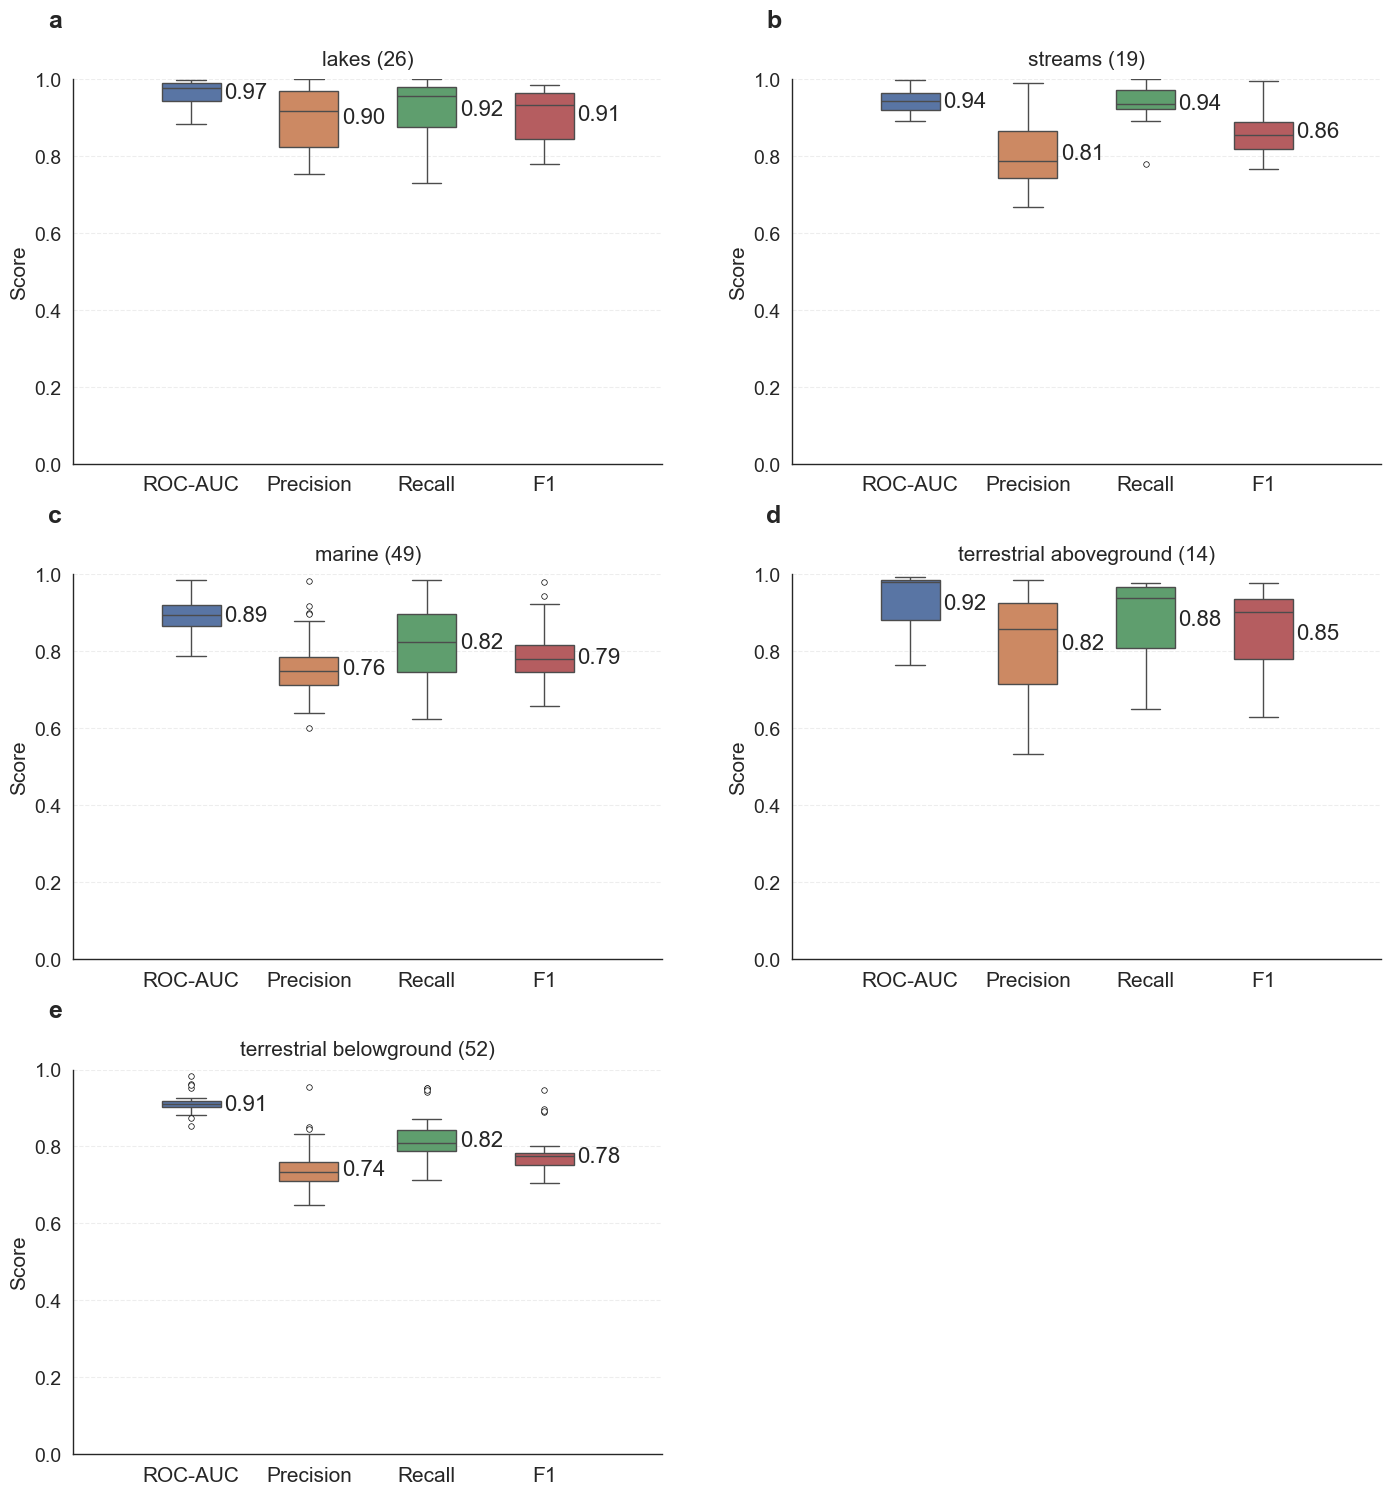

In [3]:
import os
import glob
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper")
sns.set_style("white")

# === Paths ===
results_dir = "../../../src/matlab/data/result_wlnm_dir_neg_k60_evaluate_unseen-false/prediction_scores_logs"
ecosystem_file = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"

METRIC_ORDER = ["ROC_AUC", "Precision", "Recall", "F1Score"]
xtick_labels = ["ROC-AUC", "Precision", "Recall", "F1"]
MIN_NODES = 40

# Seaborn "deep" first 4 colors: blue, orange, green, red
metric_palette = dict(zip(METRIC_ORDER, sns.color_palette("deep", 4)))

# === Load ecosystem metadata ===
df_ecosystem = pd.read_csv(ecosystem_file)

def normalize_colname(s: str) -> str:
    return (
        s.strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )

# Detect node-count column robustly
node_candidates = {"n_nodes", "num_nodes", "nodes", "nodecount", "n", "s"}
norm_map = {normalize_colname(c): c for c in df_ecosystem.columns}
node_col = next((norm_map[k] for k in node_candidates if k in norm_map), None)

if node_col is None:
    raise RuntimeError(
        "Could not find a node-count column in ecosystem metadata. "
        "Please add one (e.g., 'S', 'nodes', 'num_species', 'node_count')."
    )

# === Load result CSVs and stack ===
csv_files = glob.glob(os.path.join(results_dir, "*_mass_results_random_wlnm_dir_neg.csv"))
dfs = []

for file in csv_files:
    df = pd.read_csv(file)
    df["Foodweb"] = os.path.basename(file).split("_results_")[0]
    dfs.append(df)

if not dfs:
    raise RuntimeError("No result CSV found. Check the path or pattern.")

df_all = pd.concat(dfs, ignore_index=True)

# === Merge metrics with ecosystem metadata ===
df_merged = pd.merge(
    df_all,
    df_ecosystem[["Foodweb", "EcosystemType", node_col]],
    on="Foodweb",
    how="left"
)

# === Apply node-count filter ===
before_n = df_merged["Foodweb"].nunique()
df_merged = df_merged[df_merged[node_col] >= MIN_NODES].copy()
after_n = df_merged["Foodweb"].nunique()

print(f"Filtered food webs by size: kept {after_n} / {before_n} (>= {MIN_NODES} nodes).")

# === Prepare long-format data ===
df_plot = df_merged.melt(
    id_vars=["Foodweb", "TrainRatio", "EcosystemType", "ExpID"],
    value_vars=METRIC_ORDER,
    var_name="Metric",
    value_name="Value"
)

df_plot["TrainRatio"] = df_plot["TrainRatio"].astype(str)

# === Preferred ecosystem order ===
preferred_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystems_present = (
    df_merged["EcosystemType"]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .tolist()
)

eco_lookup = {eco.lower(): eco for eco in ecosystems_present}

ecosystem_order = [
    eco_lookup[eco]
    for eco in preferred_ecosystem_order
    if eco in eco_lookup
]

ecosystem_order += [
    eco for eco in ecosystems_present
    if eco.lower() not in set(preferred_ecosystem_order)
]

# === Panel labels ===
labels_map = (
    df_merged[["Foodweb", "EcosystemType"]]
    .drop_duplicates()
    .groupby("EcosystemType")["Foodweb"]
    .nunique()
    .to_dict()
)
labels_map = {eco: f"{eco} ({n})" for eco, n in labels_map.items()}

# === Filter TrainRatio = 60 ===
subset = df_plot[pd.to_numeric(df_plot["TrainRatio"], errors="coerce") == 60.0].copy()
if subset.empty:
    raise RuntimeError("No rows for TrainRatio = 60.0. Check how TrainRatio is stored.")

subset["Metric"] = pd.Categorical(
    subset["Metric"],
    categories=METRIC_ORDER,
    ordered=True
)

# === Plot: 2 panels per row, styled to match previous figure ===
n_panels = len(ecosystem_order)
n_cols = 2
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(14, 5 * n_rows),
    sharey=False
)

axes = np.array(axes).reshape(-1)
panel_letters = list("abcdefghijklmnopqrstuvwxyz")

for i, eco in enumerate(ecosystem_order):
    ax = axes[i]
    sub = subset[subset["EcosystemType"] == eco].copy()

    if sub.empty:
        ax.set_axis_off()
        continue

    sns.boxplot(
        data=sub,
        x="Metric",
        y="Value",
        order=METRIC_ORDER,
        palette=metric_palette,
        # hue="Metric",
        legend=False,
        width=0.5,
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markeredgewidth": 0.5,
            "linestyle": "none",
        },
        ax=ax,
    )

    # Annotate mean per box
    for j, metric in enumerate(METRIC_ORDER):
        vals = sub.loc[sub["Metric"] == metric, "Value"].dropna()
        if vals.empty:
            continue

        stat = vals.mean()
        ax.text(
            j + 0.28,
            stat,
            f"{stat:.2f}",
            ha="left",
            va="center",
            fontsize=16,
        )

    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

    ax.set_title(labels_map.get(eco, eco), fontsize=15, pad=10)
    ax.set_xlabel("")
    ax.set_xticks(range(len(METRIC_ORDER)))
    ax.set_xticklabels(xtick_labels, fontsize=15)

    ax.set_ylabel("Score", fontsize=15)
    ax.tick_params(axis="y", labelleft=True, labelsize=14)

    ax.set_xlim(-1, len(METRIC_ORDER) - 1 + 1)
    ax.set_ylim(0, 1.0)

    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    ax.grid(False, axis="x")
    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[i],
        xy=(0, 1.1),
        xycoords="axes fraction",
        xytext=(-8, 6),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=18,
        fontweight="bold",
        annotation_clip=False,
    )

# Hide unused axes
for j in range(n_panels, len(axes)):
    axes[j].set_axis_off()

fig.tight_layout(rect=[0, 0, 1, 1], w_pad=5)
plt.show()

[INFO] Foodwebs with Nodes > 40: 157
[INFO] Foodwebs in results before filter: 290
[INFO] Foodwebs in results after filter: 157


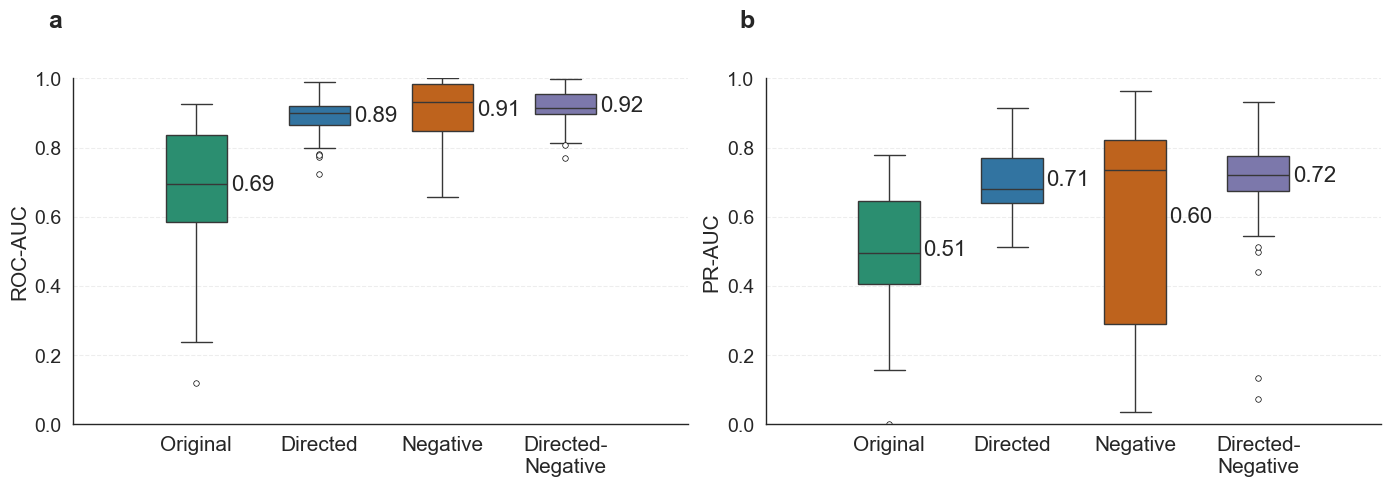

In [8]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# =========================
# Style (match old snippet)
# =========================
sns.set_theme(context="paper", style="white")


# =========================
# Config
# =========================
RESULTS_DIR_ORIGINAL = Path("../../../src/matlab/data/result_wlnm_original_k60_evaluate_unseen-false/prediction_scores_logs")
RESULTS_DIR_DIRECTED = Path("../../../src/matlab/data/result_wlnm_directed_k60_evaluate_unseen-false/prediction_scores_logs")
RESULTS_DIR_NEGATIVE = Path("../../../src/matlab/data/result_wlnm_negative_k60_evaluate_unseen-false/prediction_scores_logs")
RESULTS_DIR_DIR_NEG  = Path("../../../src/matlab/data/result_wlnm_dir_neg_k60_evaluate_unseen-false/prediction_scores_logs")

FOODWEB_CSV = Path("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")

METRICS = ["ROC_AUC", "PR_AUC"]
K_TARGET = None
K_COL = "K"
NODES_THRESHOLD = 40

GLOB_PATTERN_ORIGINAL = "*_tax_mass_results_random_wlnm_original.csv"
GLOB_PATTERN_DIRECTED = "*_tax_mass_results_random_wlnm_directed.csv"
GLOB_PATTERN_NEGATIVE = "*_tax_mass_results_random_wlnm_negative.csv"
GLOB_PATTERN_DIR_NEG  = "*_tax_mass_results_random_wlnm_dir_neg.csv"


# =========================
# Helpers
# =========================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in [
        "_results_", "_result_", "_results",
        "_random", "_tax_mass", "_tax", "_mass"
    ]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)


def parse_foodweb_from_name(fname: str) -> str:
    base = Path(fname).name
    if "_results_" in base:
        return base.split("_results_")[0]
    return Path(fname).stem


def coerce_numeric(df: pd.DataFrame, cols) -> pd.DataFrame:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def load_one_csv(csv_path: Path, version: str):
    df = pd.read_csv(csv_path)

    present_metrics = [m for m in METRICS if m in df.columns]
    if not present_metrics:
        print(f"[SKIP] Missing all metrics {METRICS}: {csv_path.name}")
        return None

    df = coerce_numeric(df, METRICS + [K_COL])

    if K_TARGET is not None and K_COL in df.columns:
        df = df[df[K_COL] == K_TARGET].copy()
        if df.empty:
            return None

    out = {
        "Foodweb": parse_foodweb_from_name(csv_path.name),
        "Version": version,
        "n_rows": int(len(df)),
        "file": csv_path.name,
        "folder": str(csv_path.parent),
    }

    valid_any = False
    for metric in METRICS:
        if metric in df.columns:
            vals = df[metric].dropna().values
            out[f"{metric}_mean"] = float(np.mean(vals)) if vals.size else np.nan
            if vals.size:
                valid_any = True
        else:
            out[f"{metric}_mean"] = np.nan

    if not valid_any:
        return None

    return out


def load_folder(folder: Path, pattern: str, version: str):
    csv_files = sorted(folder.glob(pattern))
    if not csv_files:
        raise FileNotFoundError(
            f"No files found in {folder.resolve()} matching: {pattern}"
        )

    rows = []
    for p in csv_files:
        rec = load_one_csv(p, version=version)
        if rec is not None:
            rows.append(rec)

    return rows


# =========================
# Load all CSVs (four folders)
# =========================
rows = []
rows += load_folder(RESULTS_DIR_ORIGINAL, GLOB_PATTERN_ORIGINAL, version="original")
rows += load_folder(RESULTS_DIR_DIRECTED, GLOB_PATTERN_DIRECTED, version="directed")
rows += load_folder(RESULTS_DIR_NEGATIVE, GLOB_PATTERN_NEGATIVE, version="negative")
rows += load_folder(RESULTS_DIR_DIR_NEG,  GLOB_PATTERN_DIR_NEG,  version="dir_neg")

df_all = pd.DataFrame(rows)

if df_all.empty:
    raise RuntimeError("No valid rows after loading folders. Check patterns or CSV columns.")


# =========================
# Apply NODE_THRESHOLD logic
# =========================
meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next((c for c in meta.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta.columns if c.lower() == "nodes"), None)

if fw_col is None or nodes_col is None:
    raise ValueError("Could not find 'Foodweb' and 'Nodes' columns in FOODWEB_CSV.")

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
df_all["FW_KEY"] = df_all["Foodweb"].apply(normalize_fw_label)

meta_filtered = meta.loc[meta[nodes_col] > NODES_THRESHOLD, ["FW_KEY", nodes_col]].copy()
allowed_fw_keys = set(meta_filtered["FW_KEY"].unique())

print(f"[INFO] Foodwebs with Nodes > {NODES_THRESHOLD}: {len(allowed_fw_keys)}")
print(f"[INFO] Foodwebs in results before filter: {df_all['FW_KEY'].nunique()}")

df_all = df_all[df_all["FW_KEY"].isin(allowed_fw_keys)].copy()

print(f"[INFO] Foodwebs in results after filter: {df_all['Foodweb'].nunique()}")

if df_all.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes > {NODES_THRESHOLD}.")


# =========================
# Optional: enforce one row per Foodweb per Version
# =========================
mean_cols = [f"{metric}_mean" for metric in METRICS]
df_all = (
    df_all
    .groupby(["Foodweb", "Version"], as_index=False)[mean_cols]
    .mean()
)


# =========================
# Plot: 1x2 boxplots comparing versions
# =========================
order = ["original", "directed", "negative", "dir_neg"]
label_map = {
    "original": "Original",
    "directed": "Directed",
    "negative": "Negative",
    "dir_neg": "Directed-\nNegative",
}
palette = {
    "original": "#7570b3",
    "directed": "#1f78b4",
    "negative": "#d95f02",
    "dir_neg": "#1b9e77",
}

panel_metrics = ["ROC_AUC", "PR_AUC"]
panel_letters = ["a", "b"]
panel_ylabels = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, metric, letter in zip(axes, panel_metrics, panel_letters):
    ycol = f"{metric}_mean"

    sns.boxplot(
        data=df_all,
        x="Version",
        y=ycol,
        order=order,
        palette=[palette[o] for o in order],
        hue="Version",
        legend=False,
        width=0.5,
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markeredgewidth": 0.5,
            "linestyle": "none",
        },
        ax=ax,
    )

    # Annotate mean per box
    for j, version_name in enumerate(order):
        vals = df_all.loc[df_all["Version"] == version_name, ycol].dropna()
        if vals.empty:
            continue

        stat = vals.mean()
        ax.text(
            j + 0.28,
            stat,
            f"{stat:.2f}",
            ha="left",
            va="center",
            fontsize=16,
        )

    if ax.get_legend() is not None:
        ax.get_legend().remove()

    ax.set_xlabel("")
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([label_map[o] for o in order], rotation=0, fontsize=15)
    ax.set_ylabel(panel_ylabels[metric], fontsize=15)
    ax.set_title("")
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis="y", labelleft=True, labelsize=14)
    ax.set_xlim(-1, len(order) - 1 + 1)
    ax.yaxis.set_major_locator(plt.MaxNLocator(6))
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    sns.despine(ax=ax)

    ax.annotate(
        letter,
        xy=(0, 1.1), xycoords="axes fraction",
        xytext=(-8, 8), textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=18,
        fontweight="bold",
        annotation_clip=False,
    )

plt.tight_layout()
plt.show()

[INFO] Foodwebs with Nodes > 40: 157
[INFO] Foodwebs in results before filter: 290
[INFO] Foodwebs in results after filter: 157


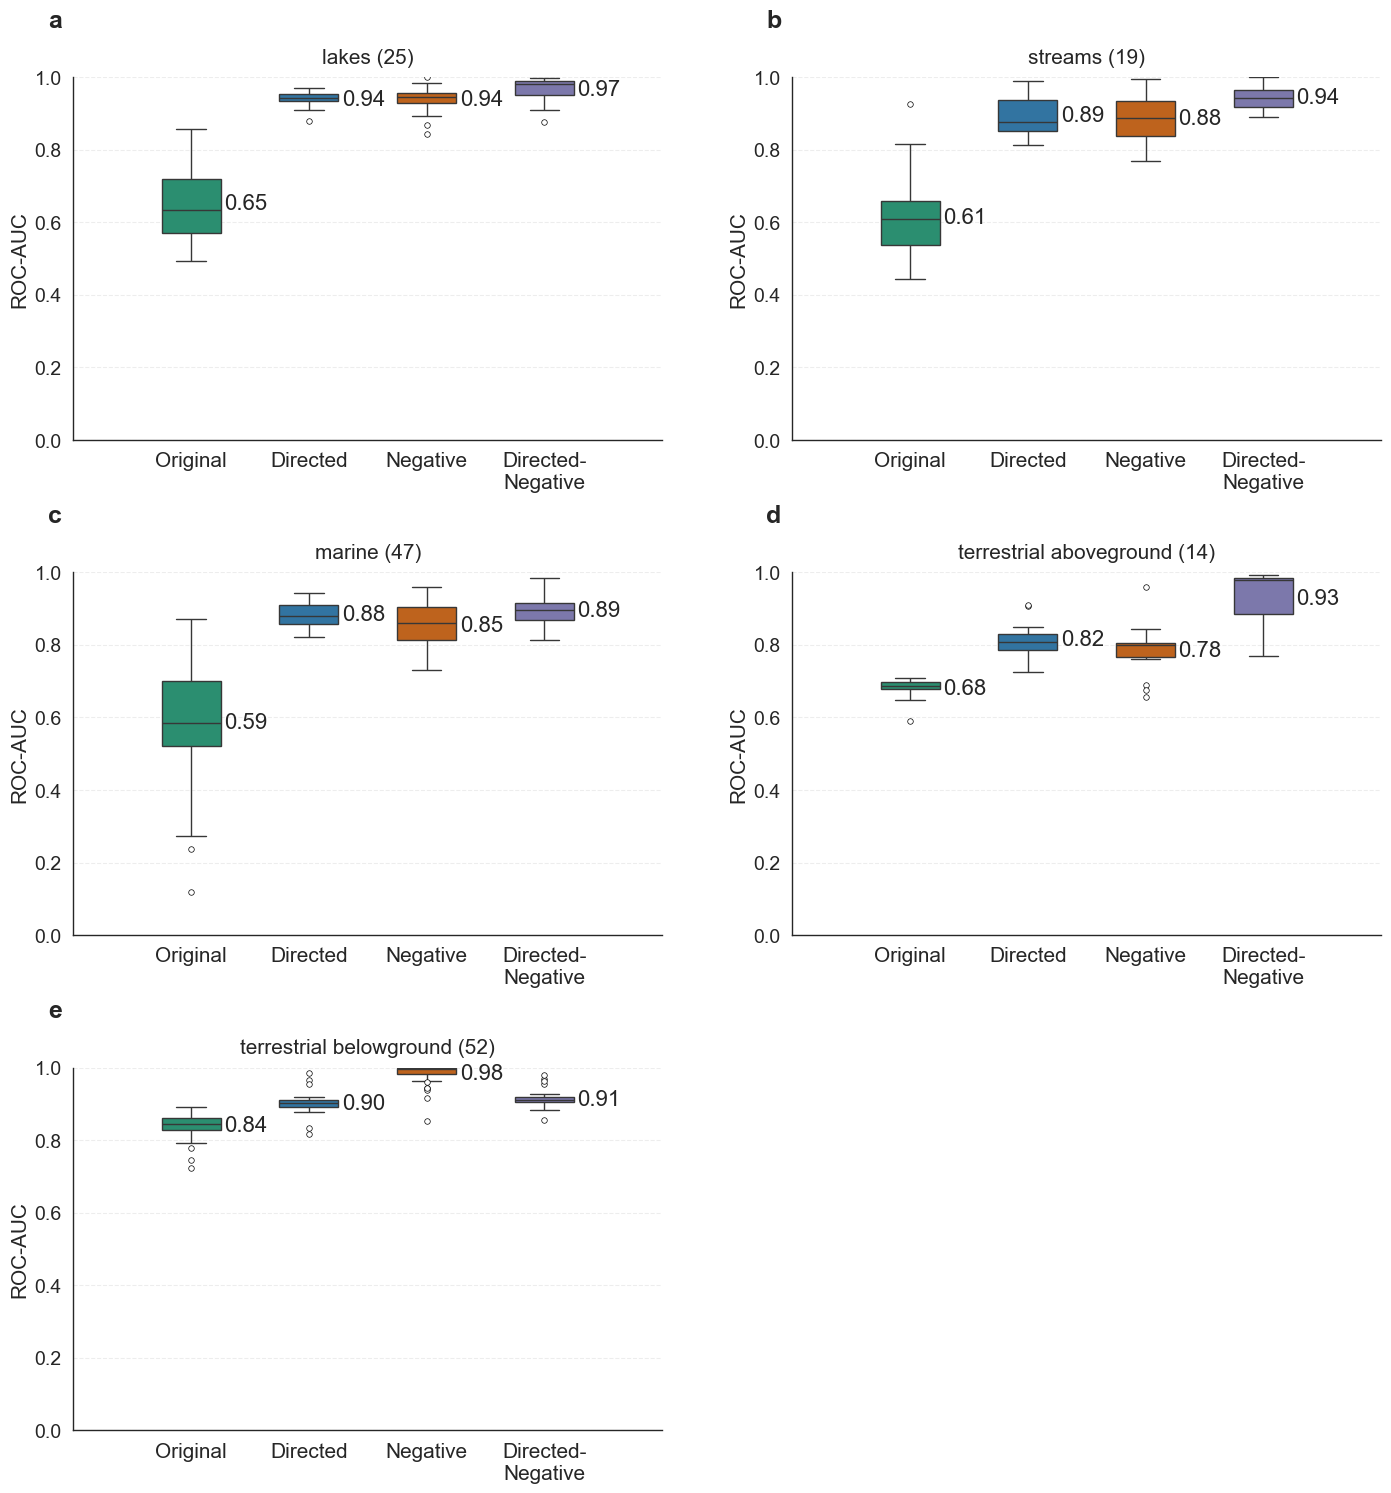

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt


# =========================
# Style (match old snippet)
# =========================
sns.set_theme(context="paper", style="white")


# =========================
# Config
# =========================
RESULTS_DIR_ORIGINAL = Path("../../../src/matlab/data/result_wlnm_original_k60_evaluate_unseen-false/prediction_scores_logs")
RESULTS_DIR_DIRECTED = Path("../../../src/matlab/data/result_wlnm_directed_k60_evaluate_unseen-false/prediction_scores_logs")
RESULTS_DIR_NEGATIVE = Path("../../../src/matlab/data/result_wlnm_negative_k60_evaluate_unseen-false/prediction_scores_logs")
RESULTS_DIR_DIR_NEG  = Path("../../../src/matlab/data/result_wlnm_dir_neg_k60_evaluate_unseen-false/prediction_scores_logs")

FOODWEB_CSV = Path("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")

METRIC = "ROC_AUC"
K_TARGET = None
K_COL = "K"
NODES_THRESHOLD = 40

GLOB_PATTERN_ORIGINAL = "*_tax_mass_results_random_wlnm_original.csv"
GLOB_PATTERN_DIRECTED = "*_tax_mass_results_random_wlnm_directed.csv"
GLOB_PATTERN_NEGATIVE = "*_tax_mass_results_random_wlnm_negative.csv"
GLOB_PATTERN_DIR_NEG  = "*_tax_mass_results_random_wlnm_dir_neg.csv"


# =========================
# Helpers
# =========================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in [
        "_results_", "_result_", "_results",
        "_random", "_tax_mass", "_tax", "_mass"
    ]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)


def parse_foodweb_from_name(fname: str) -> str:
    base = Path(fname).name
    if "_results_" in base:
        return base.split("_results_")[0]
    return Path(fname).stem


def coerce_numeric(df: pd.DataFrame, cols) -> pd.DataFrame:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def load_one_csv(csv_path: Path, version: str):
    df = pd.read_csv(csv_path)

    if METRIC not in df.columns:
        print(f"[SKIP] Missing metric '{METRIC}': {csv_path.name}")
        return None

    df = coerce_numeric(df, [METRIC, K_COL])

    if K_TARGET is not None and K_COL in df.columns:
        df = df[df[K_COL] == K_TARGET].copy()
        if df.empty:
            return None

    vals = df[METRIC].dropna().values
    if vals.size == 0:
        return None

    out = {
        "Foodweb": parse_foodweb_from_name(csv_path.name),
        "Version": version,
        "n_rows": int(len(df)),
        "file": csv_path.name,
        "folder": str(csv_path.parent),
        f"{METRIC}_mean": float(np.mean(vals)),
    }

    return out


def load_folder(folder: Path, pattern: str, version: str):
    csv_files = sorted(folder.glob(pattern))
    if not csv_files:
        raise FileNotFoundError(
            f"No files found in {folder.resolve()} matching: {pattern}"
        )

    rows = []
    for p in csv_files:
        rec = load_one_csv(p, version=version)
        if rec is not None:
            rows.append(rec)

    return rows


# =========================
# Load all CSVs (four folders)
# =========================
rows = []
rows += load_folder(RESULTS_DIR_ORIGINAL, GLOB_PATTERN_ORIGINAL, version="original")
rows += load_folder(RESULTS_DIR_DIRECTED, GLOB_PATTERN_DIRECTED, version="directed")
rows += load_folder(RESULTS_DIR_NEGATIVE, GLOB_PATTERN_NEGATIVE, version="negative")
rows += load_folder(RESULTS_DIR_DIR_NEG,  GLOB_PATTERN_DIR_NEG,  version="dir_neg")

df_all = pd.DataFrame(rows)

if df_all.empty:
    raise RuntimeError("No valid rows after loading folders. Check patterns or CSV columns.")


# =========================
# Apply NODE_THRESHOLD + EcosystemType logic
# =========================
meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next((c for c in meta.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta.columns if c.lower() == "nodes"), None)
eco_col = next(
    (c for c in meta.columns if c.lower() in ["ecosystemtype", "ecosystem", "ecosystem_type"]),
    None
)

if fw_col is None or nodes_col is None or eco_col is None:
    raise ValueError("Could not find 'Foodweb', 'Nodes', and 'EcosystemType' columns in FOODWEB_CSV.")

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
df_all["FW_KEY"] = df_all["Foodweb"].apply(normalize_fw_label)

meta_filtered = meta.loc[
    meta[nodes_col] > NODES_THRESHOLD,
    ["FW_KEY", eco_col, nodes_col]
].copy()
meta_filtered = meta_filtered.rename(columns={eco_col: "EcosystemType"})
meta_filtered["EcosystemType"] = meta_filtered["EcosystemType"].astype(str).str.strip()

allowed_fw_keys = set(meta_filtered["FW_KEY"].unique())

print(f"[INFO] Foodwebs with Nodes > {NODES_THRESHOLD}: {len(allowed_fw_keys)}")
print(f"[INFO] Foodwebs in results before filter: {df_all['FW_KEY'].nunique()}")

df_all = df_all[df_all["FW_KEY"].isin(allowed_fw_keys)].copy()

print(f"[INFO] Foodwebs in results after filter: {df_all['Foodweb'].nunique()}")

if df_all.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes > {NODES_THRESHOLD}.")

# Merge ecosystem type into results
df_all = df_all.merge(
    meta_filtered[["FW_KEY", "EcosystemType"]].drop_duplicates(),
    on="FW_KEY",
    how="left"
)

if df_all["EcosystemType"].isna().all():
    raise ValueError("EcosystemType merge failed; all values are missing.")


# =========================
# One row per Foodweb per Version
# =========================
ycol = f"{METRIC}_mean"
df_all = (
    df_all
    .groupby(["FW_KEY", "Foodweb", "Version", "EcosystemType"], as_index=False)[[ycol]]
    .mean()
)


# =========================
# Ecosystem order + labels
# =========================
preferred_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystems_present = (
    df_all["EcosystemType"]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .tolist()
)

eco_lookup = {eco.lower(): eco for eco in ecosystems_present}

ecosystem_order = [
    eco_lookup[eco]
    for eco in preferred_ecosystem_order
    if eco in eco_lookup
]

ecosystem_order += [
    eco for eco in ecosystems_present
    if eco.lower() not in set(preferred_ecosystem_order)
]

labels_map = (
    df_all[["FW_KEY", "EcosystemType"]]
    .drop_duplicates()
    .groupby("EcosystemType")["FW_KEY"]
    .nunique()
    .to_dict()
)
labels_map = {eco: f"{eco} ({n})" for eco, n in labels_map.items()}

# =========================
# Plot: boxplots by ecosystem (2 panels per row)
# =========================
order = ["original", "directed", "negative", "dir_neg"]
label_map = {
    "original": "Original",
    "directed": "Directed",
    "negative": "Negative",
    "dir_neg": "Directed-\nNegative",
}
palette = {
    "original": "#7570b3",
    "directed": "#1f78b4",
    "negative": "#d95f02",
    "dir_neg": "#1b9e77",
}

n_panels = len(ecosystem_order)
n_cols = 2
n_rows = int(np.ceil(n_panels / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(7 * n_cols, 5 * n_rows),
    sharey=False
)

axes = np.array(axes).reshape(-1)
panel_letters = list("abcdefghijklmnopqrstuvwxyz")

for i, eco in enumerate(ecosystem_order):
    ax = axes[i]
    sub = df_all[df_all["EcosystemType"] == eco].copy()

    if sub.empty:
        ax.set_axis_off()
        continue

    sns.boxplot(
        data=sub,
        x="Version",
        y=ycol,
        order=order,
        palette=[palette[o] for o in order],
        hue="Version",
        legend=False,
        width=0.5,
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markeredgewidth": 0.5,
            "linestyle": "none",
        },
        ax=ax,
    )

    # Annotate mean per box
    for j, version_name in enumerate(order):
        vals = sub.loc[sub["Version"] == version_name, ycol].dropna()
        if vals.empty:
            continue

        stat = vals.mean()
        ax.text(
            j + 0.28,
            stat,
            f"{stat:.2f}",
            ha="left",
            va="center",
            fontsize=16,
        )

    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

    ax.set_title(labels_map.get(eco, eco), fontsize=15, pad=10)
    ax.set_xlabel("")
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([label_map[o] for o in order], rotation=0, fontsize=15)

    # Show y-axis label and numeric scale on BOTH columns
    ax.set_ylabel("ROC-AUC", fontsize=15)
    ax.tick_params(axis="y", labelleft=True, labelsize=14)

    ax.set_xlim(-1, len(order) - 1 + 1)
    ax.set_ylim(0, 1.0)

    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    ax.grid(False, axis="x")
    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[i],
        xy=(0, 1.1),
        xycoords="axes fraction",
        xytext=(-8, 6),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=18,
        fontweight="bold",
        annotation_clip=False,
    )

# Hide any unused axes
for j in range(n_panels, len(axes)):
    axes[j].set_axis_off()

fig.tight_layout(rect=[0, 0, 1, 1], w_pad=5)
plt.show()